# Coursework Set week 4

**Common remarks**:

* Deadline: Sunday at 23:59h for the week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: Isabelle Rosa Frank
* Username: irfrank
* Student number: S6414117
* Group (AS1, etc.): AS5

-----

In [1]:
totalpoints = currentpoints = 0

### Monte Carlo Error Propagation (4 pt) <font color='red'><b>COURSEWORK</b></font>

One of the classical Physic Lab experiment is to use pendulum to calculate the local gravitational acceleration, ``g``, from the measurements of the pendulum length ``L`` and the oscillation period ``T``.

The formula is expressed as follows:

$$ g=\frac{4\pi^2 L}{T^2} $$

You have got a set of measurements of $L=1.00\pm0.01\ \mathrm{(m)}$ and $T=2.01\pm0.02\ \mathrm{(s)}$.

* Like in Physics Lab, use Tyler expansion described above to propagate the error. Write your derivation in Markdown.

* Calculate the error of the derived ``g``.

* Apply Monte Carlo error propagation to estimate the value and uncertainty of ``g``.

* Make appropriate comments.

* Compare the two results.

$$\sigma_g = \sqrt{(\frac{4\pi^2}{T^2})^2\sigma_L^2+(\frac{-8\pi^2L}{T^3})^2\sigma_T^2}$$

In [2]:
from math import *
import numpy as np
#define variables
L=1.00          #in m
error_L=0.01    #in m
T=2.01          #in s
error_T=0.02    #in s

#using Taylor expansion
#formula for calculating g and error of g
g=(4*(pi**2)*L)/T**2      #in m/s^2
error_g=((((4*pi**2)/T**2)**2)*(error_L**2)+(((-8*(pi**2)*L)/T**3)**2)*error_T**2)**0.5   #in m/s^2
print (f"The result using Taylor expansion is g= {g} ± {error_g} m/s^2")

#using Monte Carlo error propagation
n=100000
L_samples= np.random.normal(1.00,0.01,n)     #create random samples for L
T_samples= np.random.normal(2.01,0.02,n)     #create random samples for T

g=4*pi**2 *L_samples/T_samples**2            #calculate g with those samples
value_g=np.mean(g)                           #calculatethe mean of g
error1_g=np.std(g)                           #calculate the standard deviation
print (f"The result using Monte Carlo error propagation is g= {value_g}± {error_g} m/s^2")

The result using Taylor expansion is g= 9.77164367326488 ± 0.2176313753358241 m/s^2
The result using Monte Carlo error propagation is g= 9.77373624517926± 0.2176313753358241 m/s^2


comparison: values are close to being the same.

In [3]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Complex roots of a quadratic equation (4 pt) <font color='red'><b>COURSEWORK</b></font>
  
Use the information in the notebook about complex numbers to write a program that can calculate the (complex) roots of a quadratic equation with the quadratic formula:

$$ y=ax^2+bx+c $$

The requirement of this program is as follows:

* User can supply constants ``a``, ``b`` and ``c`` with Python function `input()`.
* The program can deal with complex roots.
* Your program must print the equation with its constants and its roots.
* The solutions must be inserted to the original equation to prove that $f(x)=0$.

**Answer**:

In [5]:
from math import *
import cmath
#input for a,b and c
a=float(input("Give a value for a:"))
b=float(input("Give a value for b:"))
c=float(input("Give a value for c:"))

print(f"the equation: y={a}x^2 + {b}x + {c}")

#calculate value under root to determine if there is a complex number
v=b**2 - 4*a*c

#print the three cases
#if a=0, no result
if a==0:
    print("no result")
    
#if v>= 0, real result
elif v>= 0:
    x1=(-b + sqrt(v))/(2*a)
    x2=(-b - sqrt(v))/(2*a)
    print (f"x1={x1}")
    print (f"x2={x2}")
#if v<0, root is negative, complex result
else:
    x1=(-b + cmath.sqrt(v))/(2*a)
    x2=(-b - cmath.sqrt(v))/(2*a)
    print (f"x1={x1}")
    print (f"x2={x2}")

#put solutions into original equations

f_x1=a*x1**2 + b*x1 +c
f_x2=a*x2**2 + b*x2 +c

#print equation with rounded result
print(f"({a}*{x1})**2 + {b}*{x1} + {c}= {f_x1:.2f}")
print(f"({a}*{x2})**2 + {b}*{x2} + {c}= {f_x2:.2f}")

Give a value for a:2
Give a value for b:54
Give a value for c:2
the equation: y=2.0x^2 + 54.0x + 2.0
x1=-0.03708798216374021
x2=-26.96291201783626
(2.0*-0.03708798216374021)**2 + 54.0*-0.03708798216374021 + 2.0= -0.00
(2.0*-26.96291201783626)**2 + 54.0*-26.96291201783626 + 2.0= 0.00


In [ ]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Area under a Gaussian (6 pt) <font color='red'><b>COURSEWORK</b></font>

A one dimensional Gaussian function is given by:

$$f(x) = A\ e^{\frac{-{(x-x_0)}^2}{2 \sigma^2}} + z_0$$

$A$ is the amplitude, $x_0$ is the position of the peak, $\sigma$ is the width of the peak
and $z_0$ is the offset in $y$.  

This function can be written in Python as follows:

```python
def gauss(x, A, x0, sigma, z0):
    return A*np.exp(-(x-x0)**2/(2*sigma**2))+z0
```

1. Set in the calling environment:
```python
    A = 1.0
    x0 = 0.0
    sig = 2.0
    z0 = 0.0
```
2. Plot this function between -10 and 10 with 200 samples.
3. Use function `scipy.integrate.quad()` to find the area between ``x=0`` and ``x=2.5``.
4. Use function `matplotlib.pyplot.fill_between()` to mark that area in your plot.
5. Calculate the area between $-\infty$ and $\infty$ ($\approx 5.01$).
6. Given is the integral for the total area under the curve:

    $$\int _{-\infty }^{\infty }Ae^{-(x-x_0)^{2}/(2\sigma^{2})}\,\mathrm{d}x=A \sigma \cdot {\sqrt {2\pi }}$$

   Calculate this area for the values of the parameters given above and prove with ``quad()`` that the two are the same.

7. Make the last part an executable script, called ``gaussarea``. The user can enter values for ``A``, ``x0``, ``sig`` and ``z0`` and the integration limits. The programme then calculates the area under the curve between the integration limits using function ``quad()``. The programme must includes a plot of the curve, the integration area, and the value of that area in a legend.
8. Insert the generated plot in a separate markdown cell below your code cell, and upload your script to GitHub. Provide your GitHub website link in the notebook too for TA to check. 
   
**Answers**:   

The Area between x=0 and x=2.5 is 1.9769788548675902 with error 2.1948874438710744e-14


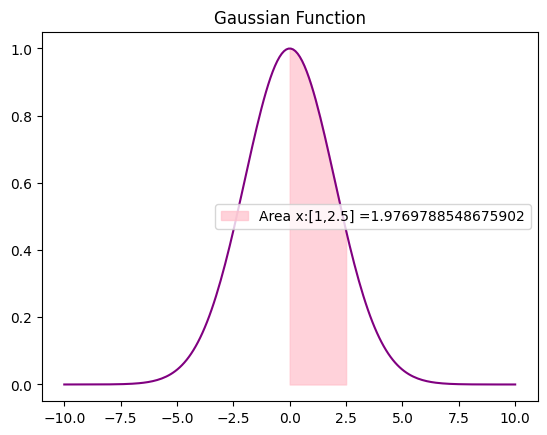

The Area between x=-inf and x=inf is 5.013256549262001 with error 6.333282352159531e-09
first equation: 5.013256549262001
second equation: 5.0132565492620005


In [6]:
from scipy import integrate
from math import *
import numpy as np
import matplotlib.pyplot as plt
def gauss(x, A, x0, sigma, z0):
    return A*np.exp(-(x-x0)**2/(2*sigma**2))+z0
A = 1.0
x0 = 0.0
sig = 2.0
z0 = 0.0
x=np.linspace(-10,10,200)
y=gauss(x, A, x0, sig, z0)

plt.plot(x,y, color="purple")
plt.title("Gaussian Function")

area, error =integrate.quad(gauss,0,2.5, args=(A, x0, sig, z0))
print(f"The Area between x=0 and x=2.5 is {area} with error {error}")

x_fill=np.linspace(0,2.5,100)
y_fill=gauss(x_fill,A,x0,sig,z0)
plt.fill_between(x_fill,y_fill,alpha=0.7, color="pink", label=f"Area x:[1,2.5] ={area}")
plt.legend()
plt.show()

area_inf, error_inf =integrate.quad(gauss,-np.inf,np.inf, args=(A, x0, sig, z0))
print(f"The Area between x=-inf and x=inf is {area_inf} with error {error_inf}")

total_area1, error_1=integrate.quad(gauss,-np.inf,np.inf, args=(A, x0, sig, z0))
total_area2=A*sig*(2*pi)**0.5
print(f"first equation: {total_area1}")
print(f"second equation: {total_area2}")

Give your value for A:2
Give your value for x0:3
Give your value for sig:4
Give your value for z0:5
Give your value for the lower bound:2
Give your value for the upper bound:2
The Area between x=2.0 and x=2.0 is 0.0 with error 0.0


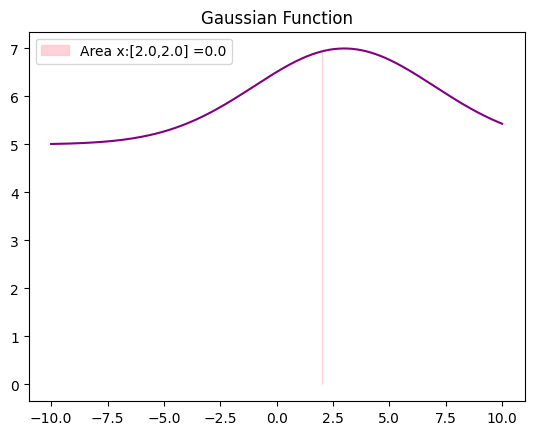

In [9]:
from scipy import integrate
from math import *
import numpy as np
import matplotlib.pyplot as plt
def gauss(x, A, x0, sigma, z0):
    return A*np.exp(-(x-x0)**2/(2*sigma**2))+z0
A = float(input("Give your value for A:"))
x0 = float(input("Give your value for x0:"))
sig = float(input("Give your value for sig:"))
z0 = float(input("Give your value for z0:"))
x=np.linspace(-10,10,200)
y=gauss(x, A, x0, sig, z0)

plt.plot(x,y, color="purple")
plt.title("Gaussian Function")

a=float(input("Give your value for the lower bound:"))
b=float(input("Give your value for the upper bound:"))
area, error =integrate.quad(gauss,a,b, args=(A, x0, sig, z0))
print(f"The Area between x={a} and x={b} is {area} with error {error}")

x_fill=np.linspace(a,b,100)
y_fill=gauss(x_fill,A,x0,sig,z0)
plt.fill_between(x_fill,y_fill,alpha=0.7, color="pink", label=f"Area x:[{a},{b}] ={area}")
plt.legend()
plt.show()


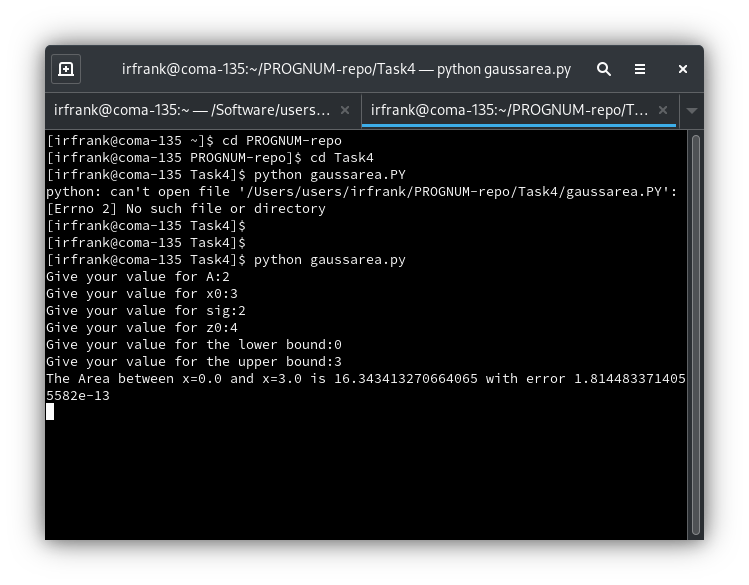

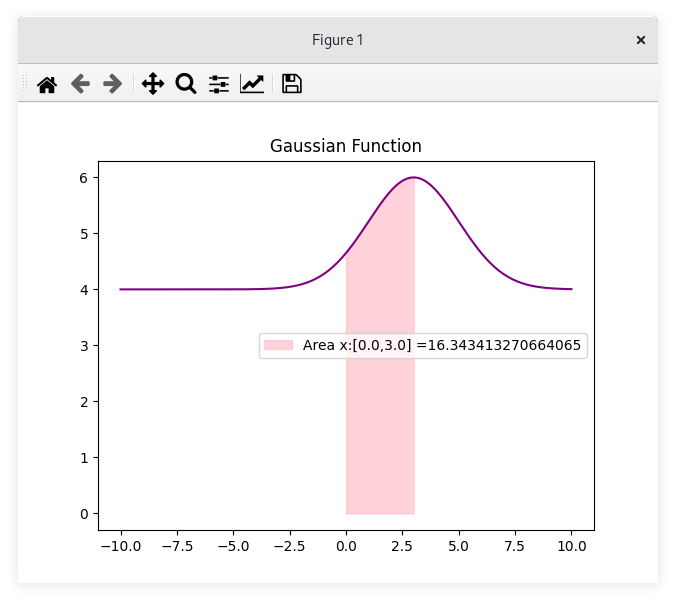

In [ ]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

### Calculate integral of a user supplied function (6 pt) <font color='red'><b>COURSEWORK</b></font>

Write a programme that calculates the integral of any function from the user input using ``eval()``, which is a string representing a function and a variable (floating number) for which the function will be evaluated.

* Call from ``numpy import sin, cos, exp, pi`` to apply these functions and constants in your code.
* Use ``scipy.integrate.quad()`` to calculate the integral of the formula below between $x=0$ and $x=\pi$
* Use Monte Carlo Integration to calculate the integral of the formula below for $x=0$ and $x=\pi$

$$ f(x)=x^4+e^{\sin{x}+\cos{x}} $$

Make the function robust with try/except clauses. Demonstrate exceptions for wrong expressions and unknown functions in an expression (NameError) etc. Print messages that tell a user what they have done wrong!

Make the above code an executable script called ``interate_user_function``, and upload to GitHub.

* Create a separate cell, and use SymPy expression to calculate the integral of the formula below for $x=0$ and $x=\pi$.

In [10]:
from math import *
import numpy as np
from numpy import sin, cos, exp, pi
from scipy import integrate

#calculate integral of any function given

f= input("Give a function depending on x:")

def function_user(f,x):
    try:
        return eval(f)
    except NameError:
        print("Name Error: Unknown variable")
    except SyntaxError:
        print("Syntax Error: invalid mathematical expression")
    except Exceptions:
        print("Unknown Error")

print(function_user(f,2))

#calculate integral with scipy.integrate.quad()

def function(x):
    f=x**4 + e**(sin(x)+cos(x))
    return f

a=0
b=pi
area, error=integrate.quad(function,a,b)
print(f"The Area between x={a} and x={b} is {area} with error {error}")
    
#monte carlo integration
x=np.random.uniform(a, b, size=1000000)
y_values=function(x)
integral=(b-a)*np.mean(y_values)
print(f"The Monte Carlo integration result: {integral}")

Give a function depending on x:W
Name Error: Unknown variable
None
The Area between x=0 and x=3.141592653589793 is 68.72932272689113 with error 8.854230135489868e-10
The Monte Carlo integration result: 68.65641018152051


In [11]:
#using sympy to calculate the integral
import sympy as sym
x=sym.symbols('x')

integral=sym.integrate(x**4 + sym.exp(sym.sin(x)+sym.cos(x)), (x, 0 ,sym.pi))

print(integral)
print(integral.evalf())

Integral(x**4 + exp(sin(x) + cos(x)), (x, 0, pi))
68.7293227268911


In [ ]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

### Plotting Hertzsprung–Russell (HR) diagram (6 pt) <font color='red'><b>COURSEWORK</b></font>

``Hertzsprung-Russell (HR) diagram``, which indicates the stellar evolution, is an important astrophysical plot graphing stellar luminosity (brightness, absolute magnitude) against surface temperature (or colour). This diagram clearly states the evolutionary pathways of stars and where they are in their lifetime. With this, we classify several important stages of a star's life -- main sequence stars, giants, or white dwarfs. 

In this exercise, a combined APOGEE/Gaia star catalog has been prepared for you to create an HR diagram -- download the catalogue from the BrightSpace: ``APOGEE+Gaia_stars.fits``

* To read FITS file, you need AstroPy, which is a library that is widely used in Astronomy.

```python
from astropy.io import fits

# Open the FITS file
hdul = fits.open('APOGEE_stars.fits')

# Access the primary data (in this case, it is a Table)
data = hdul[1].data  # Often, the first extension contains the table
colnames = hdul[1].columns.names # List of the column names
```

* "data" is a AstroPy data class, but it can be used like a ndarray as follows.

```python
print(data[0]) # The first row of the catalogue
print(data['STARFLAG']) # List all rows in the column of "STARFLAG"
print(data['STARFLAG'][:10]) # Print the first 10 elements in the column of "STARFLAG"
print(data['STARFLAG'][-10:]) # Print the last 10 elements in the column of "STARFLAG"
```

* Firstly, let's select data with good quality and robust measurements using the following criteria:
    * STARFLAG == 0
    * ASPCAPFLAG == 0
    * SNR > 10
    * GAIAEDR3_PARALLAX/ GAIAEDR3_PARALLAX_ERROR > 5
    * GAIAEDR3_PHOT_G_MEAN_MAG is not NaN value
    * GAIAEDR3_PHOT_BP_MEAN_MAG is not NaN value
    * GAIAEDR3_PHOT_RP_MEAN_MAG is not NaN value

* From the selected data, let's randomly choose about **80% of the data** for plotting the HR diagram. 

* The HR diagram contains
    * $x$-axis: colour -- BP-RP
    * $y$-axis: absolute magnitude -- $M_G$


**<span style="color:red">Warning</span>**: note that from observation, we only have apparent magnitude (i.e. observed magnitude). To convert into absolute magnitude requires **Distance Modulus**: 

$$ M_G = m_G + 5\log10{(\mathrm{parallax}/1000)} + 5 $$

* Apply a rough binary classification scheme to separate giant branch and main sequence (MS) stars.
    * Giant branch: $ M_G<3.5 $ and $(BP-RP)>0.8$
    * MS: assume the rest of the data is MS

* It seems that we do not have sufficient samples in the White Dwarf (WD) region. Use the following criteria to draw vertical and horizontal lines, as well as define a box indicating the location of WD on the HR diagram.
    * $(BP-RP)\leq0.8$ and $ M_G>10 $ (very faint)
 
* Make a scatter plot and customise it to be look like the plot shown here.

<img src="attachment:14037eb3-1593-4349-8d4a-ae0bd96b6e97.png" alt="HR Diagram" width="600">

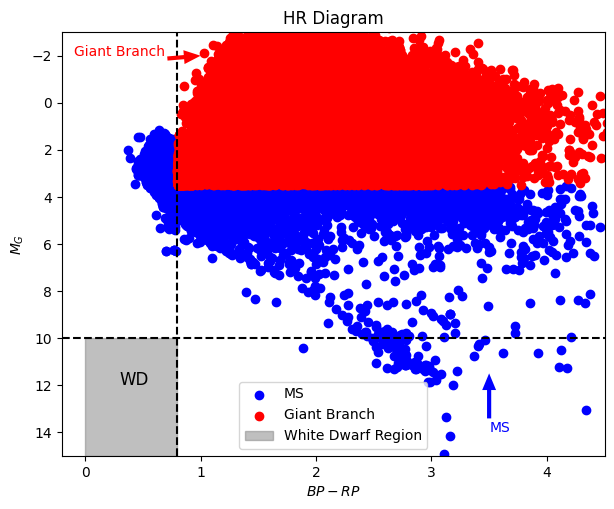

In [64]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
hdul = fits.open('APOGEE_stars.fits')
data = hdul[1].data
colnames = hdul[1].columns.names

#filter the data
mask = (
    (data['STARFLAG']==0) &
    (data['ASPCAPFLAG']==0) &
    (data['SNR']>10) &
    (data['GAIAEDR3_PARALLAX']/data['GAIAEDR3_PARALLAX_ERROR']>5) &
    (~np.isnan(data['GAIAEDR3_PHOT_G_MEAN_MAG'])) &
    (~np.isnan(data['GAIAEDR3_PHOT_BP_MEAN_MAG'])) &
    (~np.isnan(data['GAIAEDR3_PHOT_RP_MEAN_MAG']))
    )

filtered=data[mask]

#take 80% of the data
N=len(filtered)
percentage=int(0.8*N)

indices = np.random.choice(N, percentage, replace=False)
sample=filtered[indices]

#x-axis and y-axis
BP=sample['GAIAEDR3_PHOT_BP_MEAN_MAG']
RP=sample['GAIAEDR3_PHOT_RP_MEAN_MAG']
color=BP-RP

m=sample['GAIAEDR3_PHOT_G_MEAN_MAG']
parallax=sample['GAIAEDR3_PARALLAX']
M_G =m+5*np.log10(parallax/1000) + 5

#apply rough binary classification scheme
giant_branch= (M_G <3.5) & (color>0.8)
MS= ~giant_branch

#plot
plt.figure(figsize=(7,5.5))
plt.scatter(color[MS], M_G[MS], marker='o', color='blue', label='MS')
plt.scatter(color[giant_branch], M_G[giant_branch], marker='o', color='red', label='Giant Branch')
plt.gca().invert_yaxis()

#WD region
plt.axvline(0.8, color='black', linestyle='--')
plt.axhline(10, color='black', linestyle='--')
x_array=[0,0.8]
plt.fill_between(x_array, 15,10, color='grey', alpha=0.5, label='White Dwarf Region')
plt.xlabel(r'$BP-RP$')
plt.ylabel(r'$M_G$')
plt.title('HR Diagram')

#x-axis and y-axis values

plt.xticks([0,1,2,3,4])
plt.yticks([14,12,10,8,6,4,2,0,-2])
plt.xlim(-0.2,4.5)
plt.ylim(15,-3)

#text and arrows
plt.annotate('Giant Branch', 
             xy=(1,-2), 
             xytext=(-0.1,-2),
             fontsize=10,
             color='red',
             arrowprops=dict(color='red', width=3, headwidth=10, linewidth=0))
plt.annotate('MS', 
             xy=(3.5,11.5), 
             xytext=(3.5,14),
             fontsize=10,
             color='blue',
             arrowprops=dict(color='blue', width=3, headwidth=10, linewidth=0))
plt.text(x=0.3,y=12, s='WD', color='black', fontsize=12)

plt.legend()
plt.show()

In [ ]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [ ]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")